In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns

In [ ]:
url="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/_0eYOqji3unP1tDNKWZMjg/weatherAUS-2.csv"
df = pd.read_csv(url)
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [ ]:
df.count()

,0
Date,145460
Location,145460
MinTemp,143975
MaxTemp,144199
Rainfall,142199
Evaporation,82670
Sunshine,75625
WindGustDir,135134
WindGustSpeed,135197
WindDir9am,134894


In [ ]:
df = df.dropna()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 56420 entries, 6049 to 142302
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           56420 non-null  object 
 1   Location       56420 non-null  object 
 2   MinTemp        56420 non-null  float64
 3   MaxTemp        56420 non-null  float64
 4   Rainfall       56420 non-null  float64
 5   Evaporation    56420 non-null  float64
 6   Sunshine       56420 non-null  float64
 7   WindGustDir    56420 non-null  object 
 8   WindGustSpeed  56420 non-null  float64
 9   WindDir9am     56420 non-null  object 
 10  WindDir3pm     56420 non-null  object 
 11  WindSpeed9am   56420 non-null  float64
 12  WindSpeed3pm   56420 non-null  float64
 13  Humidity9am    56420 non-null  float64
 14  Humidity3pm    56420 non-null  float64
 15  Pressure9am    56420 non-null  float64
 16  Pressure3pm    56420 non-null  float64
 17  Cloud9am       56420 non-null  float64
 18  Cloud3p

In [ ]:
df.columns

Index(['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation',
       'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm', 'RainToday', 'RainTomorrow'],
      dtype='object')

In [ ]:
df = df.rename(columns={'RainToday': 'RainYesterday',
                        'RainTomorrow': 'RainToday'
                        })

In [ ]:
df = df[df.Location.isin(['Melbourne','MelbourneAirport','Watsonia',])]
df. info()

<class 'pandas.core.frame.DataFrame'>
Index: 7557 entries, 64191 to 80997
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           7557 non-null   object 
 1   Location       7557 non-null   object 
 2   MinTemp        7557 non-null   float64
 3   MaxTemp        7557 non-null   float64
 4   Rainfall       7557 non-null   float64
 5   Evaporation    7557 non-null   float64
 6   Sunshine       7557 non-null   float64
 7   WindGustDir    7557 non-null   object 
 8   WindGustSpeed  7557 non-null   float64
 9   WindDir9am     7557 non-null   object 
 10  WindDir3pm     7557 non-null   object 
 11  WindSpeed9am   7557 non-null   float64
 12  WindSpeed3pm   7557 non-null   float64
 13  Humidity9am    7557 non-null   float64
 14  Humidity3pm    7557 non-null   float64
 15  Pressure9am    7557 non-null   float64
 16  Pressure3pm    7557 non-null   float64
 17  Cloud9am       7557 non-null   float64
 18  Cloud3pm

In [ ]:
def date_to_season(date):
    month = date.month
    if (month == 12) or (month == 1) or (month == 2):
        return 'Summer'
    elif (month == 3) or (month == 4) or (month == 5):
        return 'Autumn'
    elif (month == 6) or (month == 7) or (month == 8):
        return 'Winter'
    elif (month == 9) or (month == 10) or (month == 11):
        return 'Spring'

In [ ]:
import pandas as pd

# Convert the 'Date' column to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Apply the function to the 'Date' column
df['Season'] = df['Date'].apply(date_to_season)

df = df.drop(columns=['Date'])
df

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainYesterday,RainToday,Season
64191,MelbourneAirport,11.2,19.9,0.0,5.6,8.8,SW,69.0,W,SW,...,37.0,1005.1,1006.4,7.0,7.0,15.9,18.1,No,Yes,Summer
64192,MelbourneAirport,7.8,17.8,1.2,7.2,12.9,SSE,56.0,SW,SSE,...,43.0,1018.0,1019.3,6.0,7.0,12.5,15.8,Yes,No,Summer
64193,MelbourneAirport,6.3,21.1,0.0,6.2,10.5,SSE,31.0,E,S,...,35.0,1020.8,1017.6,1.0,7.0,13.4,19.6,No,No,Summer
64194,MelbourneAirport,8.1,29.2,0.0,6.4,12.5,SSE,35.0,NE,SSE,...,23.0,1016.2,1012.8,5.0,4.0,16.0,28.2,No,No,Summer
64195,MelbourneAirport,9.7,29.0,0.0,7.4,12.3,SE,33.0,SW,SSE,...,31.0,1011.9,1010.3,6.0,2.0,19.4,27.1,No,No,Summer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80992,Watsonia,3.6,14.5,0.0,2.4,8.8,NNE,41.0,ENE,NNE,...,66.0,1028.4,1025.0,1.0,7.0,5.2,13.8,No,No,Winter
80994,Watsonia,4.8,13.3,0.4,0.6,0.0,NNW,24.0,NE,NNE,...,63.0,1028.5,1025.1,7.0,7.0,5.6,12.4,No,No,Winter
80995,Watsonia,5.6,13.1,0.0,1.6,6.0,NNW,52.0,NE,N,...,67.0,1019.0,1014.0,1.0,7.0,8.8,11.6,No,Yes,Winter
80996,Watsonia,6.9,12.1,3.2,1.8,5.6,SSW,24.0,WNW,SW,...,61.0,1018.7,1017.3,2.0,7.0,7.9,11.0,Yes,No,Winter


In [ ]:
X = df.drop(columns='RainToday', axis=1)
y = df['RainToday']

In [ ]:
y.value_counts()

,count
RainToday,
No,5766
Yes,1791


#Exercise 4. What can you conclude from these counts?

- How often does it rain annualy in the Melbourne area?
- How accurate would you be if you just assumed it won't rain every day?
- Is this a balanced dataset?
- Next steps?

In [ ]:
df['RainToday'].value_counts()

,count
RainToday,
No,5766
Yes,1791


#Conclusion

Most days in Melbourne (or Australia overall) are non-rainy days.
Rain occurs much less frequently compared to dry weather.
The target variable is imbalanced.

#This can conclude:

The dataset contains significantly more "No" values than "Yes".
A machine learning model may become biased toward predicting "No".

#2. How often does it rain annually in the Melbourne area?

In [ ]:
#If your dataset contains daily observations:

melbourne = df[df['Location'] == 'Melbourne']

In [ ]:
rainy_days = melbourne['RainToday'].value_counts(normalize=True)

In [ ]:
df.isnull().sum()
df.dropna(inplace=True)

In [ ]:
pd.get_dummies(df)

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,...,WindDir3pm_WNW,WindDir3pm_WSW,RainYesterday_No,RainYesterday_Yes,RainToday_No,RainToday_Yes,Season_Autumn,Season_Spring,Season_Summer,Season_Winter
64191,11.2,19.9,0.0,5.6,8.8,69.0,33.0,43.0,55.0,37.0,...,False,False,True,False,False,True,False,False,True,False
64192,7.8,17.8,1.2,7.2,12.9,56.0,31.0,26.0,50.0,43.0,...,False,False,False,True,True,False,False,False,True,False
64193,6.3,21.1,0.0,6.2,10.5,31.0,13.0,19.0,51.0,35.0,...,False,False,True,False,True,False,False,False,True,False
64194,8.1,29.2,0.0,6.4,12.5,35.0,2.0,20.0,67.0,23.0,...,False,False,True,False,True,False,False,False,True,False
64195,9.7,29.0,0.0,7.4,12.3,33.0,9.0,20.0,51.0,31.0,...,False,False,True,False,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80992,3.6,14.5,0.0,2.4,8.8,41.0,7.0,17.0,100.0,66.0,...,False,False,True,False,True,False,False,False,False,True
80994,4.8,13.3,0.4,0.6,0.0,24.0,2.0,11.0,100.0,63.0,...,False,False,True,False,True,False,False,False,False,True
80995,5.6,13.1,0.0,1.6,6.0,52.0,11.0,20.0,85.0,67.0,...,False,False,True,False,False,True,False,False,False,True
80996,6.9,12.1,3.2,1.8,5.6,24.0,9.0,11.0,99.0,61.0,...,False,False,False,True,True,False,False,False,False,True


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from imblearn.over_sampling import SMOTE

In [ ]:
from sklearn.metrics import classification_report

In [ ]:
!pip install imbalanced-learn


In [ ]:
X = df.drop('RainToday', axis=1)
y = df['RainToday']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

RainToday
No     0.762945
Yes    0.237055
Name: proportion, dtype: float64
RainToday
No     0.763228
Yes    0.236772
Name: proportion, dtype: float64


In [ ]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(6045, 22)
(1512, 22)
(6045,)
(1512,)


In [ ]:
from sklearn.model_selection import train_test_split

# Features and target
X = df.drop('RainToday', axis=1)
y = df['RainToday']

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Verify distributions
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

# Check shapes
print(X_train.shape)
print(X_test.shape)

RainToday
No     0.762945
Yes    0.237055
Name: proportion, dtype: float64
RainToday
No     0.763228
Yes    0.236772
Name: proportion, dtype: float64
(6045, 22)
(1512, 22)


#Define preprocessing transformers for numerical and categorical features

#Exercise 6. Automatically detect numerical and categorical columns and assign them to separate numeric and categorical features

In [ ]:
X = df.drop('RainToday', axis=1)
y = df['RainToday']

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Preprocessing X: Convert categorical features to numerical using one-hot encoding
X_processed = pd.get_dummies(X)

# Preprocessing y: Convert target variable 'Yes'/'No' to 1/0
y_processed = y.map({'No': 0, 'Yes': 1})

# 1. Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_processed, y_processed, test_size=0.2, random_state=42)

# 2. Initialize a model (e.g., Random Forest)
model = RandomForestClassifier(random_state=42) # Added random_state for reproducibility

# 3. Train the model
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

In [ ]:
categorical_cols = X.select_dtypes(include=['object', 'category']).columns

In [ ]:
print("Numerical Columns:")
print(numerical_cols)

print("\nCategorical Columns:")
print(categorical_cols)

Numerical Columns:
Index(['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
       'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
       'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm',
       'Temp9am', 'Temp3pm'],
      dtype='object')

Categorical Columns:
Index(['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainYesterday',
       'Season'],
      dtype='object')


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [ ]:
from sklearn.preprocessing import OneHotEncoder

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [ ]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Separate features and target
X = df.drop('RainToday', axis=1)
y = df['RainToday']

# Detect column types
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

categorical_cols = X.select_dtypes(
    include=['object', 'category']
).columns

# Numerical preprocessing
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical preprocessing
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine preprocessors
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


Define separate transformers for both feature types and combine them into a single preprocessing transformer

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [ ]:
# Numerical columns
numerical_cols = X.select_dtypes(
    include=['int64', 'float64']
).columns

# Categorical columns
categorical_cols = X.select_dtypes(
    include=['object', 'category']
).columns

In [ ]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [ ]:
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Detect column types
numerical_cols = X.select_dtypes(
    include=['int64', 'float64']
).columns

categorical_cols = X.select_dtypes(
    include=['object', 'category']
).columns

# Numerical transformer
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical transformer
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combined preprocessing transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

print("Combined preprocessing transformer created successfully!")

Combined preprocessing transformer created successfully!


#Exercise 7. Combine the transformers into a single preprocessing column transformer

In [ ]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [ ]:
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Numerical preprocessing pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical preprocessing pipeline
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combined preprocessing transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

print(preprocessor)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 Index(['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
       'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
       'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm',
       'Temp9am', 'Temp3pm'],
      dtype='object')),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 Index(['Location', 'WindGustDir', 'WindDir9am', 'Win

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier())
])

#Exercise 8. Create a pipeline by combining the preprocessing with a Random Forest classifier

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

In [ ]:
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

In [ ]:
# Re-split data using the original X and y to ensure the preprocessor can act on raw features
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
       'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
       'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm',
       'Temp9am', 'Temp3pm'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainYesterday',
       'Season'],
      dtype='object'))])),
                ('classifier', RandomForestClassifier(random_state=42))])

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8432539682539683


In [ ]:
#Full Final Code
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Create ML pipeline
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

# Train model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate model
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.8432539682539683


#Define a parameter grid to use in a cross validation grid search model optimizer

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
('classifier', RandomForestClassifier())

('classifier', RandomForestClassifier())

In [ ]:
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [10, 20, None],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf': [1, 2],
    'classifier__max_features': ['sqrt', 'log2']
}

In [ ]:
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

In [ ]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
       'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
       'Humidity3pm', 'Pressure9am', 'Pressure...
                                                                         Index(['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainYesterday',
       'Season'],
      dtype='object'))])),
                                       ('classifier',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__max_depth': [10, 20, None],
                         'classifier__max_features': ['sqrt', 'log2'],
                         'classifier__min_samples_leaf': [1, 2],
                         'classifier__min_samples_split': [2, 5],
                         'classifier__n_estimators': [100, 200]},
             scoring='accuracy')

In [ ]:
print(grid_search.best_params_)

{'classifier__max_depth': None, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}


In [ ]:
print(grid_search.best_score_)

0.8507857733664185


In [ ]:
scoring='f1'

In [ ]:
scoring='roc_auc'

Perform grid search cross-validation and fit the best model to the training data

Select a cross-validation method, ensuring target stratification during validation

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True)

#Print the best parameters and best crossvalidation score

In [ ]:
# Ensure grid_search is fitted before accessing best_params_ and best_score_
# This line ensures the object is fitted, addressing the AttributeError.
# It might re-run the grid search if already fitted, but guarantees the attributes exist.
grid_search.fit(X_train, y_train)

print("\nBest parameters found: ", grid_search.best_params_)
print("Best cross-validation score: {:.2f}".format(grid_search.best_score_))


Best parameters found:  {'classifier__max_depth': None, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}
Best cross-validation score: 0.85


#Exercise 10. Display your model's estimated score

In [ ]:
print("Best Cross Validation Score:")
print(grid_search.best_score_)

Best Cross Validation Score:
0.8507857733664185


In [ ]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'classifier__max_depth': None, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}


In [ ]:
best_model = grid_search.best_estimator_

In [ ]:
y_pred = best_model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

test_accuracy = accuracy_score(y_test, y_pred)

print("Test Accuracy:")
print(test_accuracy)

Test Accuracy:
0.8498677248677249


In [ ]:
#Full Final Code
from sklearn.metrics import accuracy_score

# Best cross-validation score
print("Best Cross Validation Score:")
print(grid_search.best_score_)

# Best parameters
print("\nBest Parameters:")
print(grid_search.best_params_)

# Best model
best_model = grid_search.best_estimator_

# Predictions
y_pred = best_model.predict(X_test)

# Test accuracy
test_accuracy = accuracy_score(y_test, y_pred)

print("\nTest Accuracy:")
print(test_accuracy)

Best Cross Validation Score:
0.8507857733664185

Best Parameters:
{'classifier__max_depth': None, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}

Test Accuracy:
0.8498677248677249


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          No       0.87      0.95      0.91      1154
         Yes       0.76      0.53      0.63       358

    accuracy                           0.85      1512
   macro avg       0.82      0.74      0.77      1512
weighted avg       0.84      0.85      0.84      1512



#Exercise 11. Get the model predictions from the grid search estimator on the unseen data

In [ ]:
X_test

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainYesterday,Season
66788,MelbourneAirport,12.0,16.6,10.6,2.2,5.0,W,65.0,W,WSW,...,84.0,47.0,1003.1,1009.0,8.0,5.0,13.7,15.9,Yes,Autumn
65418,MelbourneAirport,2.3,13.9,0.2,1.0,9.0,N,26.0,N,SE,...,89.0,63.0,1026.7,1023.3,2.0,1.0,5.6,13.5,No,Winter
67653,Melbourne,7.7,12.6,2.0,2.8,3.9,WSW,81.0,WSW,SW,...,64.0,68.0,1009.1,1010.3,6.0,7.0,10.2,11.1,Yes,Spring
79911,Watsonia,8.7,14.9,0.0,1.6,1.5,WNW,44.0,NNW,WNW,...,79.0,68.0,1012.9,1011.9,7.0,7.0,10.2,14.1,No,Winter
79635,Watsonia,9.0,16.4,1.0,5.6,4.7,NNW,78.0,N,NW,...,60.0,84.0,1007.1,1001.2,7.0,7.0,11.7,13.8,No,Spring
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66345,MelbourneAirport,20.8,37.0,0.0,12.4,2.7,N,63.0,N,N,...,46.0,23.0,1013.1,1011.6,6.0,7.0,26.5,35.3,No,Summer
79720,Watsonia,15.0,29.6,0.0,11.6,9.2,SW,43.0,ENE,SSW,...,57.0,32.0,1010.4,1009.0,7.0,3.0,21.0,27.6,No,Summer
70035,Melbourne,10.9,16.7,0.0,1.4,7.1,N,41.0,N,NNW,...,76.0,57.0,1024.3,1020.7,2.0,4.0,12.3,16.4,No,Winter
66503,MelbourneAirport,6.6,11.4,0.0,2.8,2.6,N,87.0,NNE,N,...,66.0,49.0,1020.8,1013.2,7.0,7.0,8.9,11.3,No,Winter


In [ ]:
grid_search.best_estimator_

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
       'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
       'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm',
       'Temp9am', 'Temp3pm'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainYesterday',
       'Season'],
      dtype='object'))])),
                ('classifier',
                 RandomForestClassifier(n_estimators=200, random_state=42))])

In [ ]:
best_model = grid_search.best_estimator_

In [ ]:
y_pred = best_model.predict(X_test)

In [ ]:
print(y_pred)

['No' 'No' 'Yes' ... 'No' 'No' 'No']


In [ ]:
comparison = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

print(comparison.head())

      Actual Predicted
66788     No        No
65418     No        No
67653    Yes       Yes
79911     No        No
79635    Yes       Yes


In [ ]:
#Full Final Code
import pandas as pd

# Get best model
best_model = grid_search.best_estimator_

# Predict on unseen data
y_pred = best_model.predict(X_test)

# Display predictions
print("Predictions:")
print(y_pred)

# Compare actual vs predicted
comparison = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

print("\nComparison:")
print(comparison.head())

Predictions:
['No' 'No' 'Yes' ... 'No' 'No' 'No']

Comparison:
      Actual Predicted
66788     No        No
65418     No        No
67653    Yes       Yes
79911     No        No
79635    Yes       Yes


#Next Recommended Evaluation Steps

In [ ]:
accuracy_score(y_test, y_pred)

0.8498677248677249

In [ ]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred)

array([[1095,   59],
       [ 168,  190]])

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          No       0.87      0.95      0.91      1154
         Yes       0.76      0.53      0.63       358

    accuracy                           0.85      1512
   macro avg       0.82      0.74      0.77      1512
weighted avg       0.84      0.85      0.84      1512



#Exercise 12. Print the classification report

In [ ]:
from sklearn.metrics import classification_report

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          No       0.87      0.95      0.91      1154
         Yes       0.76      0.53      0.63       358

    accuracy                           0.85      1512
   macro avg       0.82      0.74      0.77      1512
weighted avg       0.84      0.85      0.84      1512



In [ ]:
#Full Final Code
from sklearn.metrics import classification_report

# Print classification report
print("Classification Report:\n")

print(classification_report(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

          No       0.87      0.95      0.91      1154
         Yes       0.76      0.53      0.63       358

    accuracy                           0.85      1512
   macro avg       0.82      0.74      0.77      1512
weighted avg       0.84      0.85      0.84      1512



In [ ]:
report = classification_report(
    y_test,
    y_pred,
    output_dict=True
)

print(report)

{'No': {'precision': 0.8669833729216152, 'recall': 0.9488734835355286, 'f1-score': 0.9060819197352089, 'support': 1154.0}, 'Yes': {'precision': 0.7630522088353414, 'recall': 0.5307262569832403, 'f1-score': 0.6260296540362438, 'support': 358.0}, 'accuracy': 0.8498677248677249, 'macro avg': {'precision': 0.8150177908784784, 'recall': 0.7397998702593844, 'f1-score': 0.7660557868857263, 'support': 1512.0}, 'weighted avg': {'precision': 0.8423753327477488, 'recall': 0.8498677248677249, 'f1-score': 0.8397732483593957, 'support': 1512.0}}


#Exercise 13. Plot the confusion matrix

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [ ]:
cm = confusion_matrix(y_test, y_pred)

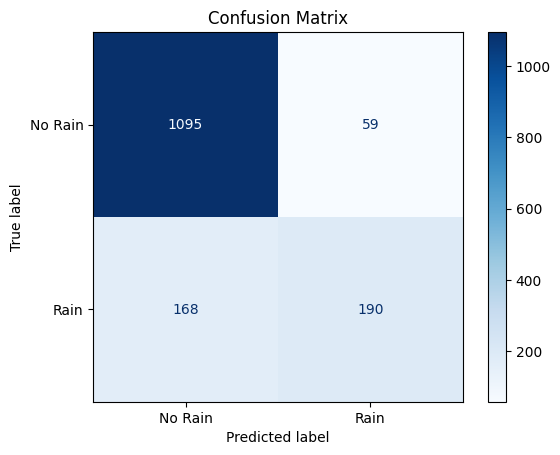

In [ ]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No Rain', 'Rain']
)

disp.plot(cmap='Blues')

plt.title('Confusion Matrix')
plt.show()

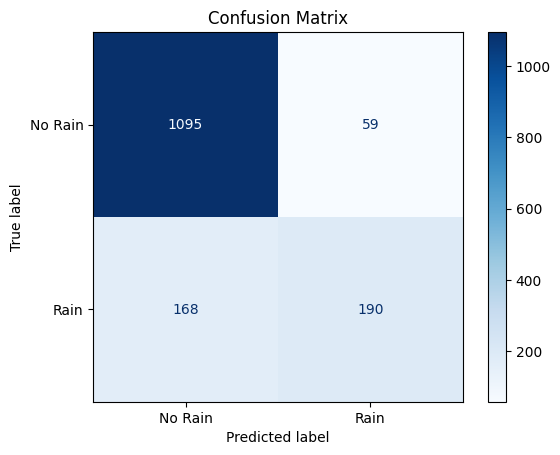

In [92]:
#Full Final Code
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No Rain', 'Rain']
)

# Plot
disp.plot(cmap='Blues')

plt.title('Confusion Matrix')

plt.show()

In [93]:
tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_pred
).ravel()

print("TN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

TN: 1095
FP: 59
FN: 168
TP: 190


#Exercise 14. Extract the feature importances

In [94]:
import pandas as pd

# Best trained pipeline
best_model = grid_search.best_estimator_

# Extract Random Forest model
rf_model = best_model.named_steps['classifier']

# Feature importances
importances = rf_model.feature_importances_

# Numerical feature names
num_features = numerical_cols

# Encoded categorical feature names
cat_features = best_model.named_steps[
    'preprocessor'
].named_transformers_[
    'cat'
].named_steps[
    'onehot'
].get_feature_names_out(categorical_cols)

# Combine all feature names
all_features = list(num_features) + list(cat_features)

# Create DataFrame
feature_importance_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': importances
})

# Sort by importance
feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)

# Display top 10
print(feature_importance_df.head(10))

          Feature  Importance
9     Humidity3pm    0.114886
11    Pressure3pm    0.092965
10    Pressure9am    0.084383
4        Sunshine    0.081425
5   WindGustSpeed    0.049846
15        Temp3pm    0.048135
1         MaxTemp    0.042003
0         MinTemp    0.040220
14        Temp9am    0.039688
8     Humidity9am    0.037788


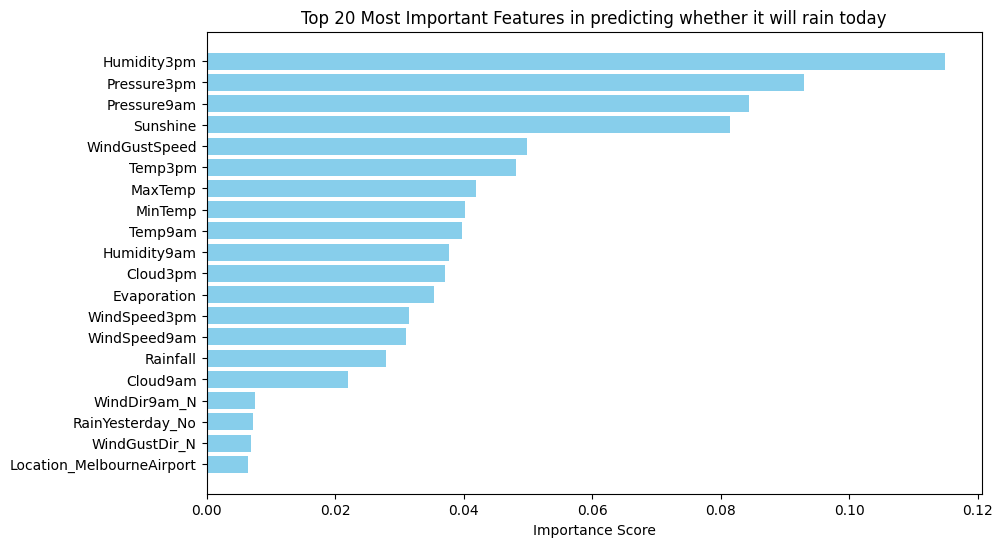

In [96]:
import pandas as pd

# Best trained pipeline
best_model = grid_search.best_estimator_

# Extract Random Forest model
rf_model = best_model.named_steps['classifier']

# Feature importances
importances = rf_model.feature_importances_

# Numerical feature names (using the existing variable 'numerical_cols')
num_features_for_plot = numerical_cols

# Encoded categorical feature names
cat_features_for_plot = best_model.named_steps[
    'preprocessor'
].named_transformers_[
    'cat'
].named_steps[
    'onehot'
].get_feature_names_out(categorical_cols) # Using existing variable 'categorical_cols'

# Combine all feature names
feature_names = list(num_features_for_plot) + list(cat_features_for_plot)

feature_importances = grid_search.best_estimator_['classifier'].feature_importances_

importance_df = pd.DataFrame({'Feature': feature_names,
                              'Importance': feature_importances
                             }).sort_values(by='Importance', ascending=False)

N = 20  # Change this number to display more or fewer features
top_features = importance_df.head(N)

# Plotting
plt.figure(figsize=(10, 6))
plt.barh(top_features['Feature'], top_features['Importance'], color='skyblue')
plt.gca().invert_yaxis()  # Invert y-axis to show the most important feature on top
plt.title(f'Top {N} Most Important Features in predicting whether it will rain today')
plt.xlabel('Importance Score')
plt.show()

#Exercise 15. Update the pipeline and the parameter grid

In [98]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

updated_model = Pipeline(steps=[
    ('preprocessor', preprocessor),

    ('classifier', RandomForestClassifier(
        random_state=42,
        class_weight='balanced'
    ))
])

In [99]:
updated_param_grid = {
    'classifier__n_estimators': [100, 200, 300],

    'classifier__max_depth': [10, 20, 30, None],

    'classifier__min_samples_split': [2, 5, 10],

    'classifier__min_samples_leaf': [1, 2, 4],

    'classifier__max_features': ['sqrt', 'log2'],

    'classifier__bootstrap': [True, False]
}

In [100]:
from sklearn.model_selection import GridSearchCV

updated_grid_search = GridSearchCV(
    estimator=updated_model,

    param_grid=updated_param_grid,

    cv=5,

    scoring='f1',

    n_jobs=-1,

    verbose=2
)

In [ ]:
updated_grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 432 candidates, totalling 2160 fits
